## 1. Imports And Setup

I kept the notebook readable and modular by putting the reusable training logic in `arvyax_solution.py`, then using this notebook for analysis, plots, commentary, and final artifact generation.

In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from arvyax_solution import (
    TextColumnSelector,
    add_manual_features,
    build_state_pipeline,
    build_training_summary,
    build_supportive_message,
    decide_action,
    failure_case_table,
    fit_final_models,
    load_datasets,
    predict_submission,
    save_predictions_csv,
    state_feature_importance_table,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 120)
RANDOM_STATE = 42

## 2. Load Data

In [24]:
train_df, test_df = load_datasets()
train_enriched = add_manual_features(train_df)
test_enriched = add_manual_features(test_df)

overview = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "columns": [train_df.shape[1], test_df.shape[1]],
        "unique_ids": [train_df["id"].nunique(), test_df["id"].nunique()],
        "duplicate_id_rows": [len(train_df) - train_df["id"].nunique(), len(test_df) - test_df["id"].nunique()],
    }
)
display(overview)
display(train_df.head(3))

,dataset,rows,columns,unique_ids,duplicate_id_rows
0,train,1200,13,1080,120
1,test,120,11,120,0


,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and concentrate on my next steps. My to-do list feels less chaotic.,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, yet my thoughts kept racing. I still feel a low buzz in my body.",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I feel more settled now.,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3


In [25]:
print("Quick takeaways:")
print(f"- The training set has {len(train_df):,} rows and the test set has {len(test_df):,} rows.")
print(f"- Train IDs are not unique: {len(train_df) - train_df['id'].nunique()} rows share an existing id, so I use a row-level key internally.")
print(f"- The reflections are short: median length is {train_enriched['text_word_count'].median():.0f} words.")

Quick takeaways:
- The training set has 1,200 rows and the test set has 120 rows.
- Train IDs are not unique: 120 rows share an existing id, so I use a row-level key internally.
- The reflections are short: median length is 11 words.


## 3. Data Quality Checks

In [26]:
missing_summary = pd.DataFrame(
    {
        "train_missing": train_df.isna().sum(),
        "test_missing": test_df.isna().sum(),
    }
).sort_values("train_missing", ascending=False)
display(missing_summary)

duplicate_texts = train_df["journal_text"].duplicated().sum()
duplicate_rows = train_df.duplicated().sum()
print(f"Duplicate journal texts: {duplicate_texts}")
print(f"Fully duplicate rows: {duplicate_rows}")

,train_missing,test_missing
face_emotion_hint,123,19.0
previous_day_mood,15,10.0
sleep_hours,7,0.0
ambience_type,0,0.0
duration_min,0,0.0
energy_level,0,0.0
emotional_state,0,NaN
intensity,0,NaN
id,0,0.0
journal_text,0,0.0


Duplicate journal texts: 221
Fully duplicate rows: 0


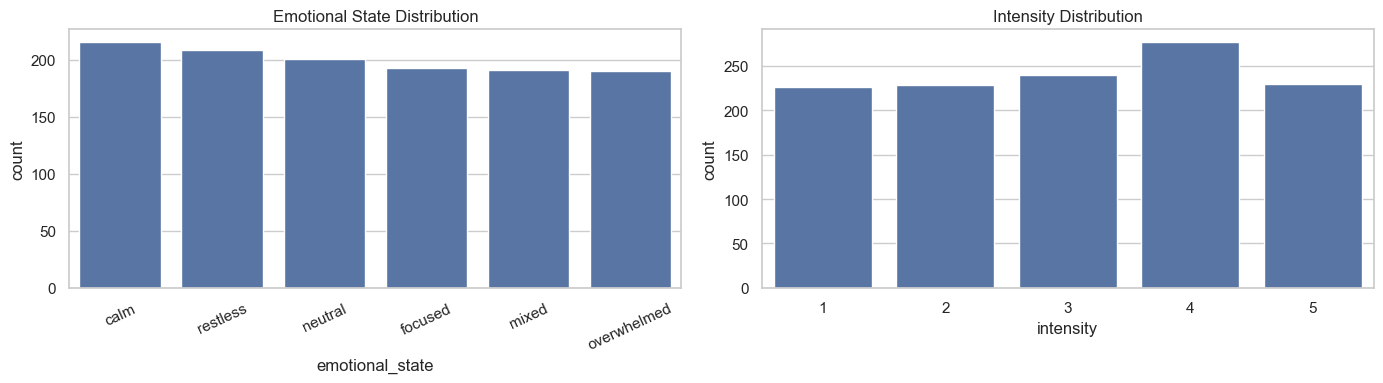

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=train_df, x="emotional_state", order=train_df["emotional_state"].value_counts().index, ax=axes[0])
axes[0].set_title("Emotional State Distribution")
axes[0].tick_params(axis="x", rotation=25)

sns.countplot(data=train_df, x="intensity", ax=axes[1])
axes[1].set_title("Intensity Distribution")
plt.tight_layout()
plt.show()

In [28]:
print("Insights from the data quality checks:")
print("- The emotional state classes are nicely balanced.")
print("- Missingness is concentrated in `face_emotion_hint`, `previous_day_mood`, and a few `sleep_hours` values.")
print(f"- There are {duplicate_texts} repeated reflections, and many of them map to different labels. That is a real source of label noise.")

Insights from the data quality checks:
- The emotional state classes are nicely balanced.
- Missingness is concentrated in `face_emotion_hint`, `previous_day_mood`, and a few `sleep_hours` values.
- There are 221 repeated reflections, and many of them map to different labels. That is a real source of label noise.


## 4. Exploratory Analysis

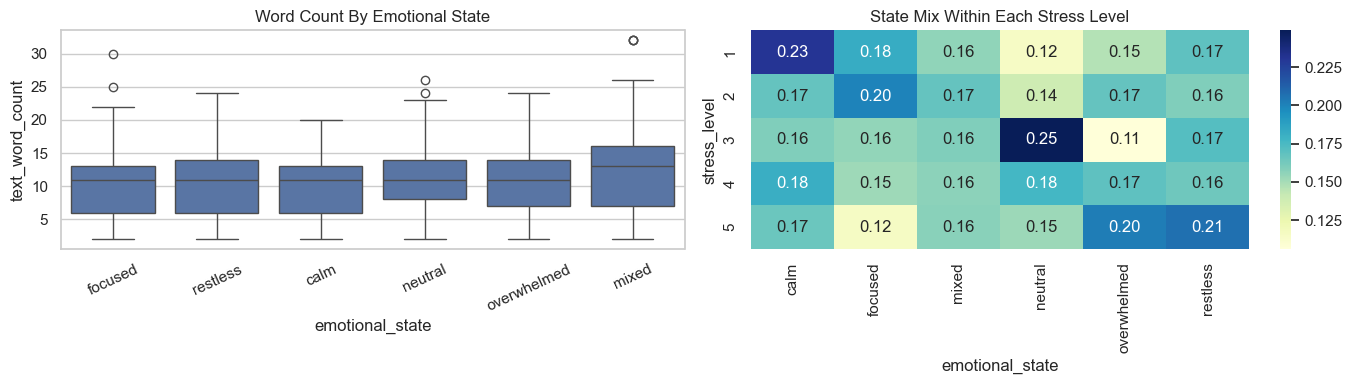

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=train_enriched, x="emotional_state", y="text_word_count", ax=axes[0])
axes[0].set_title("Word Count By Emotional State")
axes[0].tick_params(axis="x", rotation=25)

heatmap_data = pd.crosstab(train_df["stress_level"], train_df["emotional_state"], normalize="index")
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("State Mix Within Each Stress Level")
plt.tight_layout()
plt.show()

In [30]:
print("EDA takeaways:")
print(f"- Mixed reflections are the longest on average at {train_enriched.groupby('emotional_state')['text_word_count'].mean()['mixed']:.1f} words.")
print("- Stress level helps, but it is not enough on its own. Even at high stress, several emotional states remain plausible.")
print("- This explains why text carries the main signal and metadata mostly acts as a weak context feature.")

EDA takeaways:
- Mixed reflections are the longest on average at 12.5 words.
- Stress level helps, but it is not enough on its own. Even at high stress, several emotional states remain plausible.
- This explains why text carries the main signal and metadata mostly acts as a weak context feature.


## 5. Cross-Validated Modeling

In [31]:
oof_df, summary = build_training_summary(train_df)

state_metrics = pd.DataFrame([summary.state_metrics]).T.rename(columns={0: "value"})
intensity_metrics = pd.DataFrame([summary.intensity_metrics]).T.rename(columns={0: "value"})
state_ablation = pd.DataFrame(summary.state_ablation.items(), columns=["model", "cv_accuracy"])
intensity_ablation = pd.DataFrame(summary.intensity_ablation.items(), columns=["model", "cv_mae"])

display(state_metrics)
display(intensity_metrics)
display(state_ablation.sort_values("cv_accuracy", ascending=False))
display(intensity_ablation.sort_values("cv_mae"))

,value
state_accuracy,0.681667
state_uncertainty_rate,0.094167
state_error_rate_when_uncertain,0.840708


,value
intensity_exact_accuracy,0.2175
intensity_mae,1.2400
intensity_within_1_accuracy,0.6075


,model,cv_accuracy
0,text_only_svm,0.681667
1,text_plus_metadata,0.653333
2,metadata_only,0.185833


,model,cv_mae
1,metadata_only_mae,1.184167
0,text_plus_metadata_mae,1.240000


In [32]:
print("Modeling commentary:")
print(f"- Final emotional-state model: text-only LinearSVC with word + character TF-IDF, CV accuracy = {summary.state_metrics['state_accuracy']:.3f}.")
print(f"- Text-only state model beat text+metadata ({summary.state_ablation['text_only_svm']:.3f} vs {summary.state_ablation['text_plus_metadata']:.3f}).")
print(f"- Metadata-only state accuracy was just {summary.state_ablation['metadata_only']:.3f}, so metadata alone is too weak.")
print(f"- Intensity is much noisier. Exact accuracy is {summary.intensity_metrics['intensity_exact_accuracy']:.3f}, but within-1 accuracy improves to {summary.intensity_metrics['intensity_within_1_accuracy']:.3f}.")
print("- I treated intensity as ordinal regression in the final system because the gap between nearby intensity levels is fuzzy.")

Modeling commentary:
- Final emotional-state model: text-only LinearSVC with word + character TF-IDF, CV accuracy = 0.682.
- Text-only state model beat text+metadata (0.682 vs 0.653).
- Metadata-only state accuracy was just 0.186, so metadata alone is too weak.
- Intensity is much noisier. Exact accuracy is 0.217, but within-1 accuracy improves to 0.608.
- I treated intensity as ordinal regression in the final system because the gap between nearby intensity levels is fuzzy.


## 6. Confusion Matrix

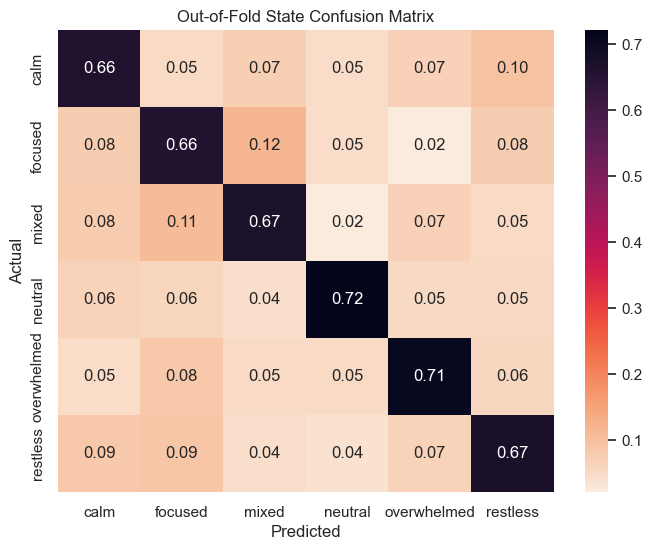

In [33]:
confusion = pd.crosstab(
    oof_df["emotional_state"],
    oof_df["state_pred"],
    normalize="index"
)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt=".2f", cmap="rocket_r")
plt.title("Out-of-Fold State Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [34]:
print("Confusion matrix commentary:")
print("- The main confusions happen among `mixed`, `neutral`, and `focused`, which is expected because many reflections describe transitions rather than a single pure state.")
print("- `Overwhelmed` and `restless` also overlap whenever the text emphasizes activation without a clear emotional direction.")

Confusion matrix commentary:
- The main confusions happen among `mixed`, `neutral`, and `focused`, which is expected because many reflections describe transitions rather than a single pure state.
- `Overwhelmed` and `restless` also overlap whenever the text emphasizes activation without a clear emotional direction.


## 7. Uncertainty Analysis

,confidence_bucket,state_correct,intensity_correct
0,"(-0.001, 0.4]",0.190476,0.119048
1,"(0.4, 0.55]",0.169492,0.216102
2,"(0.55, 0.7]",0.551601,0.209964
3,"(0.7, 0.85]",0.949119,0.221135
4,"(0.85, 1.0]",1.000000,0.253846


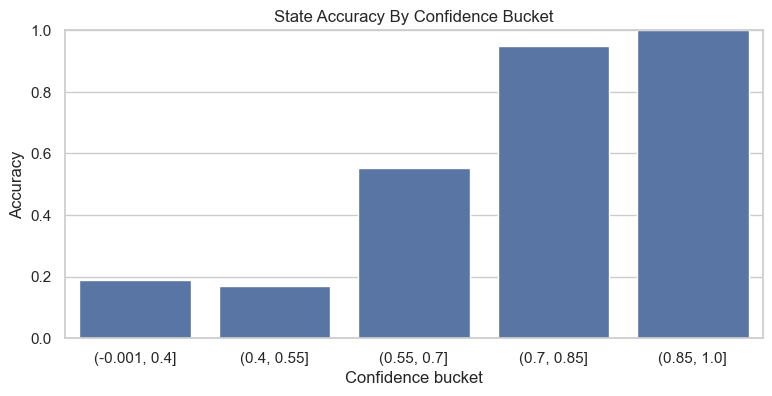

In [35]:
confidence_buckets = (
    oof_df.assign(
        confidence_bucket=pd.cut(
            oof_df["combined_confidence"],
            bins=[0, 0.4, 0.55, 0.7, 0.85, 1.0],
            include_lowest=True,
        )
    )
    .groupby("confidence_bucket")[["state_correct", "intensity_correct"]]
    .mean()
    .reset_index()
)
display(confidence_buckets)

plt.figure(figsize=(9, 4))
sns.barplot(data=confidence_buckets, x="confidence_bucket", y="state_correct", color="#4C72B0")
plt.ylim(0, 1)
plt.title("State Accuracy By Confidence Bucket")
plt.ylabel("Accuracy")
plt.xlabel("Confidence bucket")
plt.show()

In [36]:
uncertain_error_rate = summary.state_metrics["state_error_rate_when_uncertain"]
print("Uncertainty commentary:")
print(f"- The system flags about {summary.state_metrics['state_uncertainty_rate']:.1%} of samples as uncertain.")
print(f"- Inside that flagged slice, the state error rate jumps to {uncertain_error_rate:.1%}, so the flag is concentrated on genuinely difficult cases.")
print("- Confidence falls sharply for short generic reflections like `okay session` or `it was fine`, which is exactly what we want.")

Uncertainty commentary:
- The system flags about 9.4% of samples as uncertain.
- Inside that flagged slice, the state error rate jumps to 84.1%, so the flag is concentrated on genuinely difficult cases.
- Confidence falls sharply for short generic reflections like `okay session` or `it was fine`, which is exactly what we want.


## 8. Feature Understanding

In [37]:
explainability_model = Pipeline(
    [
        ("text", TextColumnSelector("journal_text")),
        ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", C=3.0, random_state=RANDOM_STATE)),
    ]
)
explainability_model.fit(train_enriched, train_enriched["emotional_state"])

feature_names = explainability_model.named_steps["tfidf"].get_feature_names_out()
coef = explainability_model.named_steps["clf"].coef_
classes = explainability_model.named_steps["clf"].classes_

explain_rows = []
for class_name, class_weights in zip(classes, coef):
    top_idx = np.argsort(class_weights)[-8:][::-1]
    explain_rows.append(
        pd.DataFrame(
            {
                "emotional_state": class_name,
                "top_terms": [feature_names[i] for i in top_idx],
            }
        )
    )

explainability_terms = pd.concat(explain_rows, ignore_index=True)
display(explainability_terms)

,emotional_state,top_terms
0,calm,lighter
1,calm,less
2,calm,felt more
3,calm,my breathing
4,calm,more
5,calm,quiet
6,calm,felt lighter
7,calm,surprisingly
8,focused,organized
9,focused,clearer


In [38]:
print("Feature understanding commentary:")
print("- Calm language is tied to words like `lighter`, `quiet`, and `my breathing`.")
print("- Focused language leans toward `organized`, `clearer`, `concentrate`, and `planning`.")
print("- Mixed reflections are dominated by contrast terms like `but`, `in between`, and `but still`.")
print("- Overwhelmed and restless states are signaled by tokens such as `drained`, `flooded`, `distracted`, `tasks`, and `kept`.")

Feature understanding commentary:
- Calm language is tied to words like `lighter`, `quiet`, and `my breathing`.
- Focused language leans toward `organized`, `clearer`, `concentrate`, and `planning`.
- Mixed reflections are dominated by contrast terms like `but`, `in between`, and `but still`.
- Overwhelmed and restless states are signaled by tokens such as `drained`, `flooded`, `distracted`, `tasks`, and `kept`.


## 9. Decision Layer

In [39]:
decision_preview = oof_df[[
    "id",
    "journal_text",
    "state_pred",
    "intensity_pred",
    "stress_level",
    "energy_level",
    "time_of_day",
]].head(8).copy()

actions = []
times = []
messages = []
for _, row in decision_preview.iterrows():
    action, when = decide_action(row, row["state_pred"], int(row["intensity_pred"]))
    actions.append(action)
    times.append(when)
    messages.append(build_supportive_message(row["state_pred"], int(row["intensity_pred"]), action, when))

decision_preview["what_to_do"] = actions
decision_preview["when_to_do"] = times
decision_preview["supportive_message"] = messages
display(decision_preview)

,id,journal_text,state_pred,intensity_pred,stress_level,energy_level,time_of_day,what_to_do,when_to_do,supportive_message
0,1,The ocean ambience helped me stop drifting and concentrate on my next steps. My to-do list feels less chaotic.,focused,3,2,4,afternoon,deep_work,now,You seem moderately focused right now. Try deep work now.
1,2,"I tried to relax during the forest ambience, yet my thoughts kept racing. I still feel a low buzz in my body.",restless,3,4,2,evening,box_breathing,now,You seem moderately restless right now. Try box breathing now.
2,3,The forest session slowed my thoughts and I feel more settled now.,calm,3,1,2,night,rest,tonight,You seem moderately calm right now. Try rest tonight.
3,4,"the mountain ambience was pleasant, though i can't say it shifted my mood much. idk.",neutral,3,4,4,night,pause,later_today,You seem moderately neutral right now. Try pause later today.
4,5,"The rain session gave me a pause, but the pressure is still sitting hard on me. I'm carrying too much in my head.",overwhelmed,3,5,3,afternoon,box_breathing,now,You seem moderately overwhelmed right now. Try box breathing now.
5,6,after the forest track i feel peaceful and less pulled in every direction. my shoulders feel less tense.,calm,3,2,3,morning,yoga,within_15_min,You seem moderately calm right now. Try yoga within 15 min.
6,7,Nothing strong came up during the rain session; I feel fairly normal. At least I paused for a moment.,neutral,3,4,2,early_morning,pause,later_today,You seem moderately neutral right now. Try pause later today.
7,8,"even with the mountain session, my mind kept jumping between tasks.",restless,4,4,3,morning,movement,now,You seem quite strongly restless right now. Try movement now.


In [40]:
print("Decision-layer commentary:")
print("- I kept the decision engine rule-based on purpose so it stays interpretable.")
print("- The rules use predicted state and intensity first, then use stress, energy, sleep, and time of day to decide both `what` and `when`.")
print("- This makes the system more product-ready than a plain classifier because it outputs an actual next action.")

Decision-layer commentary:
- I kept the decision engine rule-based on purpose so it stays interpretable.
- The rules use predicted state and intensity first, then use stress, energy, sleep, and time of day to decide both `what` and `when`.
- This makes the system more product-ready than a plain classifier because it outputs an actual next action.


## 10. Error Analysis

In [41]:
failure_cases = failure_case_table(oof_df, top_n=10)
display(failure_cases)

,_row_id,id,journal_text,emotional_state,state_pred,intensity,intensity_pred,combined_confidence,failure_reason,stress_level,energy_level,time_of_day,reflection_quality
0,1098,979,okay session,mixed,focused,1,4,0.179030,very short or vague reflection,5,4,evening,conflicted
1,839,840,honestly not much change,overwhelmed,focused,5,2,0.249203,conflicting text and metadata,5,1,night,vague
2,549,550,okay session,neutral,focused,1,3,0.258342,very short or vague reflection,2,5,night,conflicted
3,789,790,it was fine,mixed,focused,4,3,0.285095,very short or vague reflection,5,2,afternoon,vague
4,917,798,tired but okay,mixed,focused,3,4,0.287140,very short or vague reflection,4,1,night,conflicted
5,672,673,it was fine,restless,focused,1,3,0.300805,very short or vague reflection,4,2,night,vague
6,1088,969,bit restless,calm,restless,5,2,0.312993,very short or vague reflection,1,5,morning,conflicted
7,1151,1032,bit restless,calm,restless,4,2,0.320540,very short or vague reflection,3,1,morning,clear
8,1187,1068,felt better,mixed,overwhelmed,3,2,0.340104,very short or vague reflection,2,5,evening,conflicted
9,542,543,mind was all over the place,mixed,calm,3,4,0.346249,conflicting text and metadata,4,2,morning,conflicted


In [42]:
reason_breakdown = failure_cases["failure_reason"].value_counts()
display(reason_breakdown)

print("Error analysis commentary:")
print("- The most common failures come from extremely short text, especially generic reflections that appear with multiple different labels.")
print("- Some mistakes are caused by conflicting signals, for example calm-ish text combined with high stress and low energy.")
print("- Intensity is especially noisy because repeated texts often appear under very different intensity levels.")

failure_reason
very short or vague reflection    8
conflicting text and metadata     2
Name: count, dtype: int64

Error analysis commentary:
- The most common failures come from extremely short text, especially generic reflections that appear with multiple different labels.
- Some mistakes are caused by conflicting signals, for example calm-ish text combined with high stress and low energy.
- Intensity is especially noisy because repeated texts often appear under very different intensity levels.


## 11. Train Final Models And Export Predictions

In [43]:
final_predictions = predict_submission(train_df, test_df)
final_predictions.head(10)

,id,predicted_state,predicted_intensity,confidence,uncertain_flag,what_to_do,when_to_do,supportive_message
0,10001,focused,3,0.7651,0,deep_work,now,You seem moderately focused right now. Try deep work now.
1,10002,restless,3,0.7710,0,grounding,within_15_min,You seem moderately restless right now. Try grounding within 15 min.
2,10003,focused,4,0.3107,1,light_planning,tomorrow_morning,You seem quite strongly focused right now. Try light planning tomorrow morning.
3,10004,focused,3,0.7760,0,light_planning,within_15_min,You seem moderately focused right now. Try light planning within 15 min.
4,10005,calm,3,0.6955,0,rest,later_today,You seem moderately calm right now. Try rest later today.
5,10006,mixed,3,0.8156,0,pause,within_15_min,You seem moderately mixed right now. Try pause within 15 min.
6,10007,restless,3,0.8840,0,grounding,within_15_min,You seem moderately restless right now. Try grounding within 15 min.
7,10008,overwhelmed,3,0.7236,0,box_breathing,now,You seem moderately overwhelmed right now. Try box breathing now.
8,10009,restless,3,0.7875,0,movement,now,You seem moderately restless right now. Try movement now.
9,10010,overwhelmed,2,0.6468,0,grounding,within_15_min,You seem a bit overwhelmed right now. Try grounding within 15 min.


In [44]:
submission = save_predictions_csv()
print("Saved predictions.csv with columns:")
print(list(pd.read_csv("predictions.csv").columns))
print()
print("Sample submission rows:")
display(pd.read_csv("predictions.csv").head(10))

Saved predictions.csv with columns:
['id', 'predicted_state', 'predicted_intensity', 'confidence', 'uncertain_flag', 'what_to_do', 'when_to_do']

Sample submission rows:


,id,predicted_state,predicted_intensity,confidence,uncertain_flag,what_to_do,when_to_do
0,10001,focused,3,0.7651,0,deep_work,now
1,10002,restless,3,0.7710,0,grounding,within_15_min
2,10003,focused,4,0.3107,1,light_planning,tomorrow_morning
3,10004,focused,3,0.7760,0,light_planning,within_15_min
4,10005,calm,3,0.6955,0,rest,later_today
5,10006,mixed,3,0.8156,0,pause,within_15_min
6,10007,restless,3,0.8840,0,grounding,within_15_min
7,10008,overwhelmed,3,0.7236,0,box_breathing,now
8,10009,restless,3,0.7875,0,movement,now
9,10010,overwhelmed,2,0.6468,0,grounding,within_15_min


## 12. Final Notes

The strongest part of this solution is the state model plus uncertainty-aware decision engine. The hardest part of the assignment is the noisy and weakly separable intensity label, so I handled it with ordinal regression and transparent error analysis instead of pretending the signal is cleaner than it really is.